In [1]:
import numpy as np

import matplotlib.pyplot as plt                 # Manipular gráficas
from IPython.display import Image, display      # Mostrar animaciones

from EcuacionCalor import (
    primitiva_L,
    FDM_HeatModel,
    generar_DIR, generar_ROB, generar_NEU,
    fdm2d, fdm2d_graph_mesh,
    GraphType
)

GUIA DE TRABAJOS PRACTICOS Nº 2
---

# MÉTODO DE DIFERENCIAS FINITAS 2D

## Ejercicio 2

Dado el problema de transferencia de calor sobre la figura mostrada. Considere la conductividad k=1, sin reacción, una fuente G=100 distribuida uniformemente.

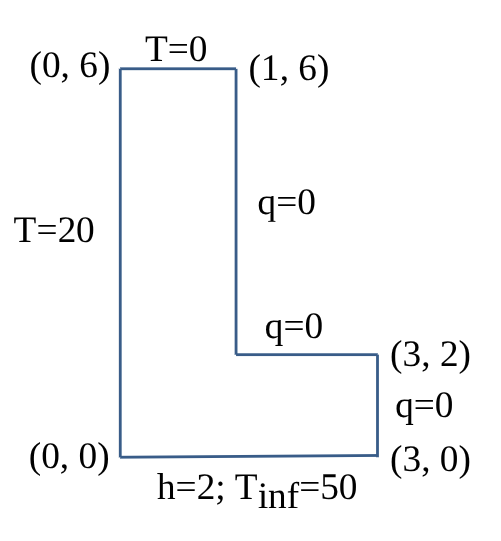

Al resolver cada ítem, evaluar distintos grados de refinamiento

### Ítem (a)

- **Resuelva el problema en estado estacionario**

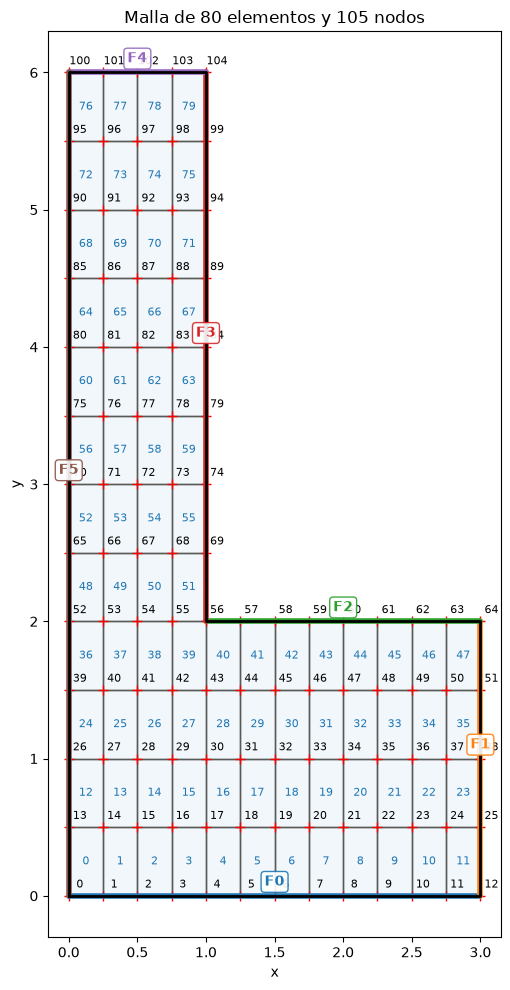

In [2]:
xnode, icone, vert, bounds = primitiva_L(x_scale=3.0, y_scale=6.0, x_subdiv=2, y_subdiv=2, plot=True)

Condiciones de contorno según el orden de `bounds`:

$F0: ~h = 2, ~T_\infty = 50$ / Normal al sur: 1

$F1: ~q = 0$ / Normal al este: 2

$F2: ~q = 0$ / Normal al norte: 3

$F3: ~q = 0$ / Normal al este: 2

$F4: ~T = 0$

$F5: ~T = 20$

In [3]:
nnoodes = len(xnode)

# Modelo de inciso (a)
model = FDM_HeatModel(
    nnodes = nnoodes,
    k = np.ones(nnoodes),
    c = np.zeros(nnoodes),
    G = np.full(nnoodes, 100.0),
    rho = 0.0,
    cp = 0.0,
    ts = -1,    # Estacionario
)

def f_constante(a):
    return lambda x,y : (a)

# Condiciones de contorno Dirichlet
DIR_F4 = generar_DIR(bounds[4], xnode, f_constante(0))
DIR_F5 = generar_DIR(bounds[5][1:], xnode, f_constante(20)) # Para el nodo de la esquina T=0

DIR = np.vstack((
    DIR_F4,
    DIR_F5,
))

# Condiciones de contorno Neumann
NEU_F1 = generar_NEU(bounds[1], xnode, f_constante(0.0), 2)
NEU_F2 = generar_NEU(bounds[2], xnode, f_constante(0.0), 3)
NEU_F3 = generar_NEU(bounds[3], xnode, f_constante(0.0), 2)

NEU = np.vstack((
    NEU_F1,
    NEU_F2,
    NEU_F3,
))

# Condiciones de contorno Robin
ROB_F0 = generar_ROB(bounds[0], xnode, f_constante(2.0), f_constante(50.0), 1)

ROB = np.vstack((
    ROB_F0,
))

PHI, Q = fdm2d(xnode, icone, DIR, NEU, ROB, model)

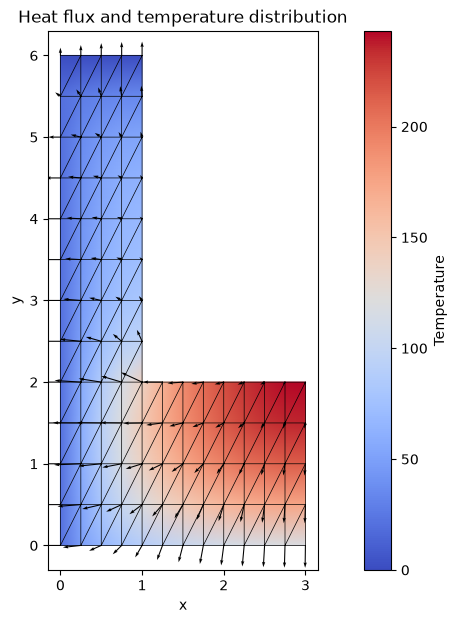

In [4]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.HEAT_FLUX, dimension=2, transient=False, mesh=True, margin=0.05);

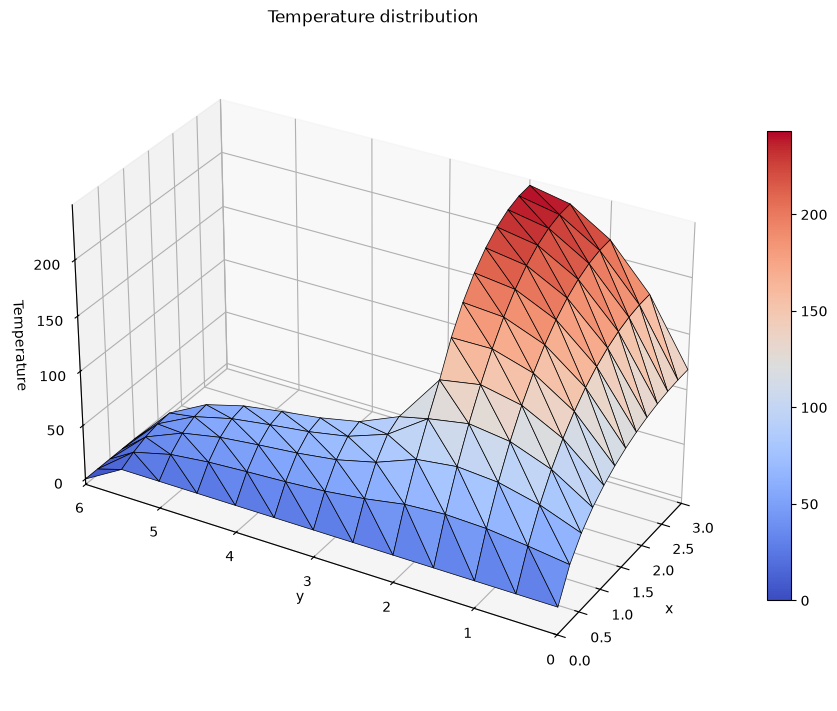

In [5]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.TEMPERATURE, dimension=3, transient=False, mesh=True, margin=0, azim=-150);

### Ítem (b)

- **Resuelva el problema en estado transiente, considerando $\rho c_p = 1$ y un paso temporal dt=0.05 . Utilizar una tolerancia de 1e-5 para considerar que la solución llegó a su estado estacionario.**

In [6]:
# Modelo de inciso (b)
model.rho = 1.0
model.cp = 1.0
model.ts = 1        # Transiente - Implícito
model.dt = 0.05
model.tol = 1E-5
model.PHI_n = np.zeros(nnoodes) # Condición inicial T(x,y,0) = 0
model.maxit = int(1E5)

PHI, Q = fdm2d(xnode, icone, DIR, NEU, ROB, model)

Implicit temporal scheme
dt = 0.05
Iter 100
Iter 200
Stop on iter  239


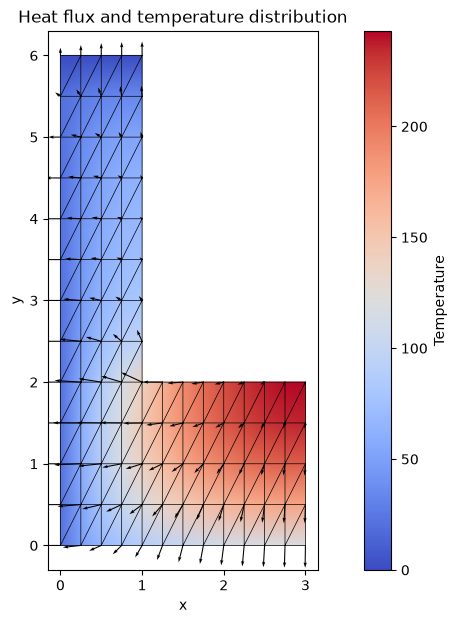

In [7]:
fdm2d_graph_mesh(xnode, icone, PHI[-1], Q[-1], graph=GraphType.HEAT_FLUX, dimension=2, transient=False, mesh=True, margin=0.05);

In [ ]:
filename = "GTP-MDF-2D_Ejercicio-2b.gif"
fig, anim = fdm2d_graph_mesh(xnode, icone, PHI, Q, delta_t = model.dt, graph=GraphType.TEMPERATURE, dimension=3, transient=True,
                             mesh=True, margin=0, fps=10, frames=50, save_path=filename, azim=-150)

plt.close()
# display(Image(filename=filename))

![](./GTP-MDF-2D_Ejercicio-2b.gif)

### Ítem (c)

- **Resuelva el problema en estado estacionario pero considerando que la fuente G=100 para $0 \leq x \leq 1$ y $0 \leq y \leq 3$. En el resto del dominio G=0**

In [9]:
G = np.zeros(nnoodes)
G[np.logical_and(xnode[:, 0] <= 1.0, xnode[:, 1] <= 3.0)] = 100.0

# Modelo de inciso (c)
model = FDM_HeatModel(
    nnodes = nnoodes,
    k = np.ones(nnoodes),
    c = np.zeros(nnoodes),
    G = G,
    rho = 1.0,
    cp = 1.0,
    ts = -1,    # Estacionario
)

PHI, Q = fdm2d(xnode, icone, DIR, NEU, ROB, model)

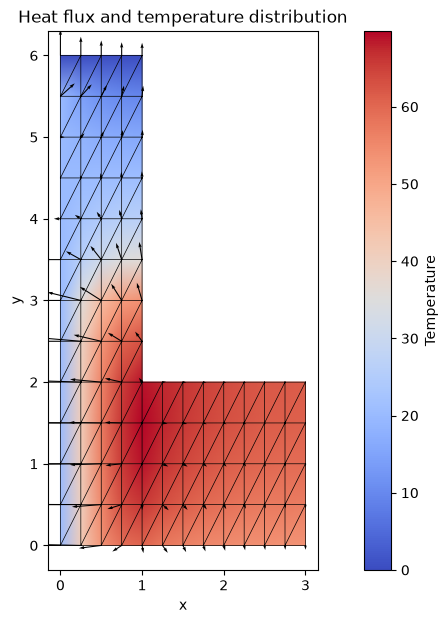

In [10]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.HEAT_FLUX, dimension=2, transient=False, mesh=True, margin=0.05);

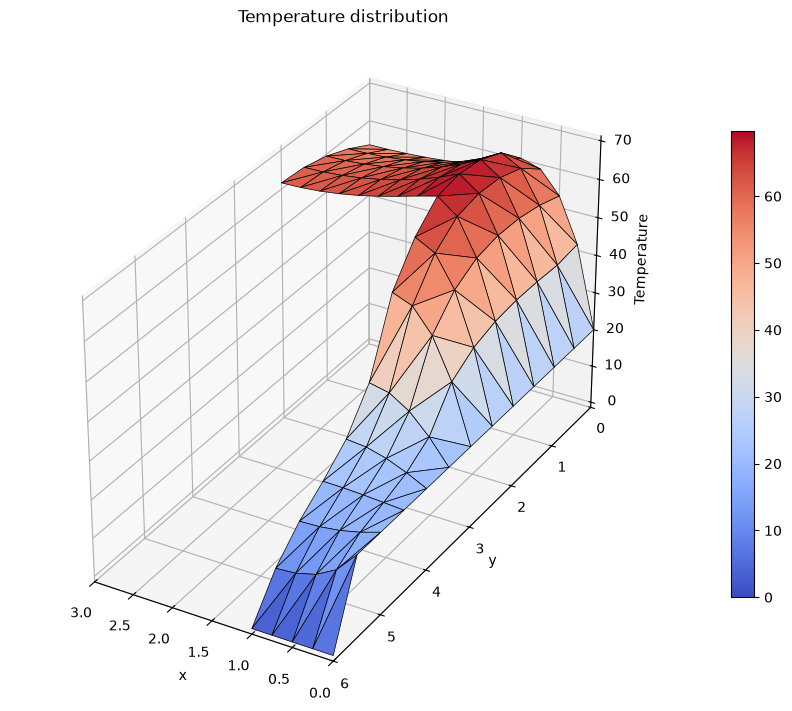

In [11]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.TEMPERATURE, dimension=3, transient=False, mesh=True, margin=0, azim=120);

### Ítem (d)

- **Resolver el ítem b pero considerar que la fuente se anula a los dos segundos de comenzado el proceso.**

In [12]:
# Modelo de inciso (d) - Fuente encendida
model = FDM_HeatModel(
    nnodes = nnoodes,
    k = np.ones(nnoodes),
    c = np.zeros(nnoodes),
    G = np.full(nnoodes, 100.0),
    rho = 1.0,
    cp = 1.0,
    ts = 1,                     # Transiente - Implícito
    dt = 0.05,
    maxit = int(2.0/0.05),      # 2 segundos
    tol = 1E-12,                # Tolerancia chica para prevenir corte por estacionario
    PHI_n = np.zeros(nnoodes),
)

PHI_1, Q_1 = fdm2d(xnode, icone, DIR, NEU, ROB, model)

# Modelo de inciso (d) - Fuente anulada
model = FDM_HeatModel(
    nnodes = nnoodes,
    k = np.ones(nnoodes),
    c = np.zeros(nnoodes),
    G = np.zeros(nnoodes),
    rho = 1.0,
    cp = 1.0,
    ts = 1,                     # Transiente - Implícito
    dt = 0.05,                  
    maxit = int(1E5),
    tol = 1E-5,                 # Corte por estacionario
    PHI_n = PHI_1[-1],            # Estado inicial: último estado con fuente encendida
)

PHI_2, Q_2 = fdm2d(xnode, icone, DIR, NEU, ROB, model)

Implicit temporal scheme
dt = 0.05
Implicit temporal scheme
dt = 0.05
Iter 100
Iter 200
Stop on iter  257


In [13]:
# Concatenar las 2 soluciones
PHI = PHI_1 + PHI_2[1:]
Q = Q_1 + Q_2[1:]

In [ ]:
filename = "GTP-MDF-2D_Ejercicio-2d.gif"
fig, anim = fdm2d_graph_mesh(xnode, icone, PHI, Q, delta_t = model.dt, graph=GraphType.TEMPERATURE, dimension=3, transient=True,
                             mesh=True, margin=0, fps=10, frames=150, save_path=filename, azim=-150)

plt.close()
# display(Image(filename=filename))

![](./GTP-MDF-2D_Ejercicio-2d.gif)